# CE49X Final Project - Conflict Situation Monitoring

This notebook is structured to satisfy Task 1-4 requirements from `Final_Project.tex`.

## Run Flow
1. Run collection scripts in `Final Project/scripts/`
2. Verify PostgreSQL tables are populated
3. Run all analysis cells in this notebook
4. Export final dashboard as `dashboard.png`


In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sqlalchemy import create_engine, text

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')


## Configuration

In [2]:
ROOT = Path.cwd()

candidate_project_dirs = [
    ROOT / 'Final Project',
    ROOT,
    ROOT.parent,
]

PROJECT_DIR = None
for p in candidate_project_dirs:
    if (p / 'scripts').exists() and (p / 'notebooks').exists() and (p / 'Final_Project.tex').exists():
        PROJECT_DIR = p
        break

if PROJECT_DIR is None:
    PROJECT_DIR = ROOT / 'Final Project'

DATA_DIR = PROJECT_DIR / 'data'
NOTEBOOK_DIR = PROJECT_DIR / 'notebooks'
DASHBOARD_PATHS = [PROJECT_DIR / 'dashboard.png', NOTEBOOK_DIR / 'dashboard.png']

default_pg_url = 'postgresql://ce49x@localhost:5432/conflict_monitoring'
sqlite_url = f"sqlite:///{(DATA_DIR / 'conflict_monitoring.db').as_posix()}"
requested_db_url = os.getenv('DATABASE_URL', default_pg_url)

# If PostgreSQL driver is missing, avoid create_engine(postgresql://...) entirely.
if requested_db_url.startswith('postgresql'):
    try:
        import psycopg2  # noqa: F401
        engine = create_engine(requested_db_url)
        with engine.connect() as conn:
            conn.execute(text('SELECT 1'))
        print('Using DB:', requested_db_url)
    except Exception as exc:
        engine = create_engine(sqlite_url)
        print('PostgreSQL unavailable, using SQLite fallback:', sqlite_url)
        print('Original DB error:', type(exc).__name__, str(exc)[:200])
else:
    engine = create_engine(requested_db_url)
    print('Using DB:', requested_db_url)

print('Project dir:', PROJECT_DIR)
print('Data dir exists:', DATA_DIR.exists())
print('Notebook dir exists:', NOTEBOOK_DIR.exists())


PostgreSQL unavailable, using SQLite fallback: sqlite:///C:/Users/alp5k/CE49X/Final Project/data/conflict_monitoring.db
Original DB error: ModuleNotFoundError No module named 'psycopg2'
Project dir: C:\Users\alp5k\CE49X\Final Project
Data dir exists: True
Notebook dir exists: True


## Task 1 - Data Collection & Assembly

If CSV files are missing, first run:
- `python "Final Project/scripts/collect_firms.py" --start 2025-01-01 --end 2025-06-30 --source VIIRS_SNPP_SP`
- `python "Final Project/scripts/collect_news_gdelt.py" --start 2025-01-01 --end 2025-06-30 --target 1200`
- `python "Final Project/scripts/setup_db.py" --firms "Final Project/data/firms_detections.csv" --news "Final Project/data/news_articles.csv"`


In [3]:
df_firms = pd.read_sql('SELECT * FROM firms_detections', engine)
df_news = pd.read_sql('SELECT * FROM news_articles', engine)

print('FIRMS shape:', df_firms.shape)
print('News shape :', df_news.shape)

display(df_firms.head())
display(df_news.head())

print('\nFIRMS missing values:')
print(df_firms.isna().sum())
print('\nNews missing values:')
print(df_news.isna().sum())


FIRMS shape: (190860, 16)
News shape : (1612, 8)


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,region
0,47.84376,36.83806,306.84,0.42,0.45,2025-01-05,9,N,VIIRS,n,2,266.54,1.34,N,0,Black_Sea_Ukraine
1,47.86589,35.14801,310.73,0.54,0.42,2025-01-05,9,N,VIIRS,n,2,272.34,2.48,N,3,Black_Sea_Ukraine
2,47.87030,35.16559,305.24,0.54,0.42,2025-01-05,9,N,VIIRS,n,2,271.24,2.25,N,2,Black_Sea_Ukraine
3,47.87556,35.16049,301.17,0.54,0.42,2025-01-05,9,N,VIIRS,n,2,269.13,0.74,N,2,Black_Sea_Ukraine
4,48.05669,37.95555,304.91,0.46,0.47,2025-01-05,9,N,VIIRS,n,2,268.16,0.75,N,2,Black_Sea_Ukraine


,title,publication_date,source,domain,url,region,collector,location_mention
0,US says it struck Iranian radar sites as Iran ...,2026-06-01 13:12:26+00:00,BBC,news.google.com,https://news.google.com/rss/articles/CBMiWkFVX...,Persian_Gulf,google_rss,Persian_Gulf
1,Iran Executes Two Men Over January Anti-Govern...,2026-06-01 07:10:59+00:00,Radio Free Europe/Radio Liberty,news.google.com,https://news.google.com/rss/articles/CBMiiAFBV...,Persian_Gulf,google_rss,Persian_Gulf
2,U.S. Says It Hit More Military Targets in Sout...,2026-06-01 06:52:03+00:00,The New York Times,news.google.com,https://news.google.com/rss/articles/CBMijAFBV...,Persian_Gulf,google_rss,Persian_Gulf
3,U.S. bombs Iranian military sites and Kuwait i...,2026-06-01 05:53:00+00:00,NPR,news.google.com,https://news.google.com/rss/articles/CBMib0FVX...,Persian_Gulf,google_rss,Persian_Gulf
4,U.S. Military Is Quietly Guiding Ships Through...,2026-05-31 20:48:58+00:00,The New York Times,news.google.com,https://news.google.com/rss/articles/CBMijAFBV...,Persian_Gulf,google_rss,Persian_Gulf



FIRMS missing values:
latitude      0
longitude     0
bright_ti4    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_ti5    0
frp           0
daynight      0
type          0
region        0
dtype: int64

News missing values:
title                0
publication_date     0
source              13
domain               0
url                  0
region               0
collector            0
location_mention     0
dtype: int64


### Task 1 Documentation: Sources, Methods, and Region Justification

**FIRMS source**
- API endpoint type: NASA FIRMS `area` CSV endpoint (`/api/area/csv/{MAP_KEY}/{SOURCE}/{BBOX}/{DAYS}/{YYYY-MM-DD}`)
- Platform/source used: `VIIRS_SNPP_SP`
- Date range: `2025-01-01` to `2025-06-30` (continuous 6 months)
- Access URL: <https://firms.modaps.eosdis.nasa.gov/api/area/>
- Access date: 2026-06-01
- Region bboxes used:
  - Black_Sea_Ukraine: `26.0,44.0,41.0,52.5`
  - Levant_EastMed: `32.0,30.0,38.5,37.8`
  - Red_Sea_Gulf_Aden: `36.0,11.0,48.0,24.0`
  - Persian_Gulf: `46.0,22.0,57.5,31.0`

**News sources**
- GDELT DOC 2.0 API (JSON article list mode)
  - URL: <https://api.gdeltproject.org/api/v2/doc/doc>
  - Access date: 2026-06-01
- Google News RSS search
  - URL: <https://news.google.com/rss>
  - Access date: 2026-06-01

**Why these regions matter for shipping and energy**
- They include major shipping chokepoints and energy corridors affecting freight costs and oil/gas volatility.
- Escalations in these zones can trigger rerouting, insurance surcharges, and fuel price shocks.
- Monitoring these zones provides operational early-warning value for maritime decision-making.

## Task 2 - Thermal Event Clustering and Spatio-Temporal Analysis

In [4]:
df_firms['acq_date'] = pd.to_datetime(df_firms['acq_date'], errors='coerce')
df_firms = df_firms.dropna(subset=['acq_date', 'latitude', 'longitude'])

# Simple event grouping: region + 2-day bins
brightness_col = 'brightness' if 'brightness' in df_firms.columns else 'bright_ti4'
df_firms['date_bin'] = df_firms['acq_date'].dt.floor('D')
df_firms['event_key'] = (
    df_firms['region'].astype(str)
    + '_'
    + df_firms['date_bin'].dt.strftime('%Y%m%d')
)

df_events = (
    df_firms.groupby('event_key', as_index=False)
    .agg(
        region=('region', 'first'),
        centroid_lat=('latitude', 'mean'),
        centroid_lon=('longitude', 'mean'),
        start_date=('acq_date', 'min'),
        end_date=('acq_date', 'max'),
        total_frp=('frp', 'sum'),
        max_brightness=(brightness_col, 'max'),
        detection_count=('latitude', 'size')
    )
)
df_events['duration_days'] = (df_events['end_date'] - df_events['start_date']).dt.days + 1
df_events['month'] = pd.to_datetime(df_events['start_date']).dt.to_period('M').astype(str)

print('Thermal events:', df_events.shape)
display(df_events.head())

df_events.to_sql('thermal_events', engine, if_exists='replace', index=False)


Thermal events: (720, 11)


,event_key,region,centroid_lat,centroid_lon,start_date,end_date,total_frp,max_brightness,detection_count,duration_days,month
0,Black_Sea_Ukraine_20250105,Black_Sea_Ukraine,47.684658,34.676033,2025-01-05,2025-01-05,202.56,354.87,55,1,2025-01
1,Black_Sea_Ukraine_20250106,Black_Sea_Ukraine,45.241025,29.970940,2025-01-06,2025-01-06,204.71,356.42,26,1,2025-01
2,Black_Sea_Ukraine_20250107,Black_Sea_Ukraine,45.195602,36.950578,2025-01-07,2025-01-07,30.96,340.35,6,1,2025-01
3,Black_Sea_Ukraine_20250108,Black_Sea_Ukraine,46.428752,32.536267,2025-01-08,2025-01-08,93.79,367.00,17,1,2025-01
4,Black_Sea_Ukraine_20250109,Black_Sea_Ukraine,45.927504,35.172371,2025-01-09,2025-01-09,229.63,354.21,51,1,2025-01


720

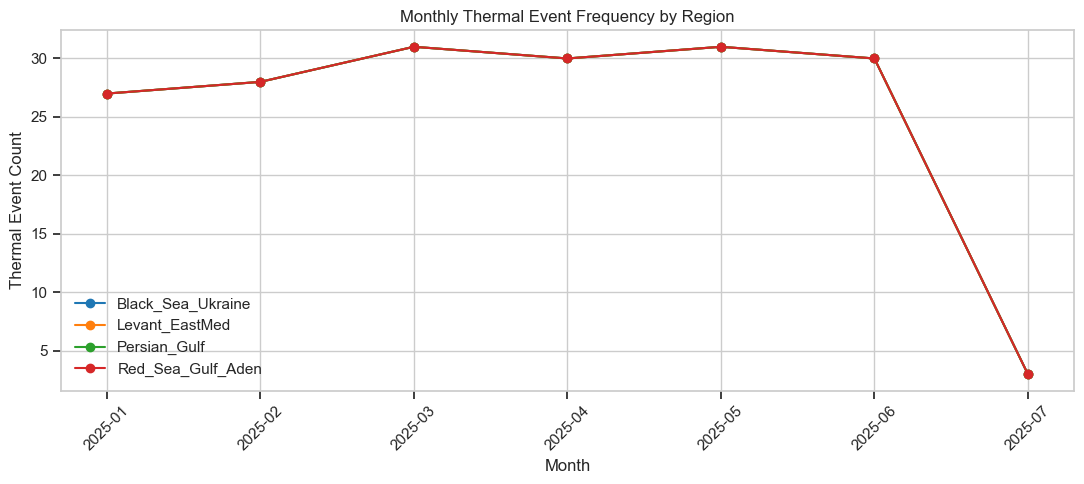

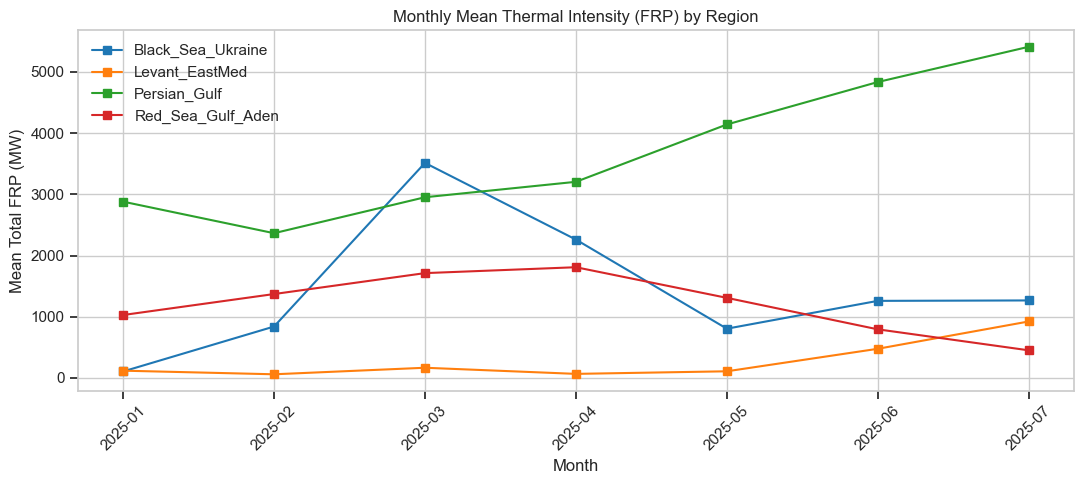

In [5]:
# Temporal plot 1: monthly event counts by region
monthly_counts = df_events.groupby(['month', 'region'], as_index=False)['event_key'].count()
monthly_counts = monthly_counts.rename(columns={'event_key': 'event_count'})

plt.figure(figsize=(11, 5))
for region, g in monthly_counts.groupby('region'):
    plt.plot(g['month'], g['event_count'], marker='o', label=region)
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Thermal Event Count')
plt.title('Monthly Thermal Event Frequency by Region')
plt.legend()
plt.tight_layout()
plt.show()

# Temporal plot 2: mean FRP by month and region
monthly_frp = df_events.groupby(['month', 'region'], as_index=False)['total_frp'].mean()
plt.figure(figsize=(11, 5))
for region, g in monthly_frp.groupby('region'):
    plt.plot(g['month'], g['total_frp'], marker='s', label=region)
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Mean Total FRP (MW)')
plt.title('Monthly Mean Thermal Intensity (FRP) by Region')
plt.legend()
plt.tight_layout()
plt.show()


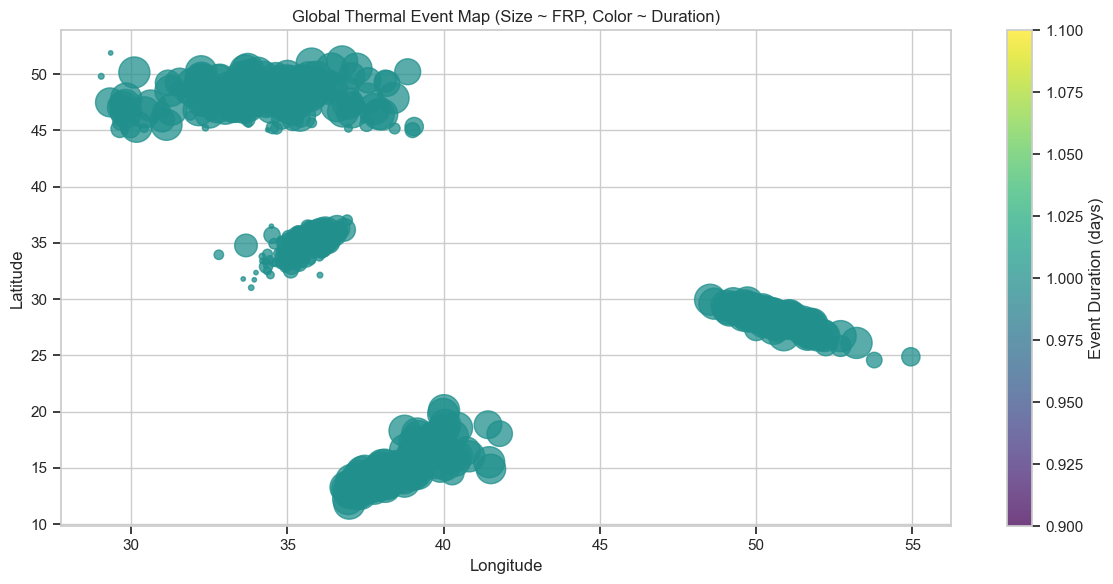

,region,total_events,total_frp
2,Persian_Gulf,180,621243.24
0,Black_Sea_Ukraine,180,269542.92
3,Red_Sea_Gulf_Aden,180,239145.54
1,Levant_EastMed,180,32321.09


In [6]:
# Spatial plots
plt.figure(figsize=(12, 6))
sc = plt.scatter(
    df_events['centroid_lon'],
    df_events['centroid_lat'],
    c=df_events['duration_days'],
    s=np.clip(df_events['total_frp'].fillna(0), 10, 500),
    cmap='viridis',
    alpha=0.75
)
plt.colorbar(sc, label='Event Duration (days)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Global Thermal Event Map (Size ~ FRP, Color ~ Duration)')
plt.tight_layout()
plt.show()

top_hotspots = (
    df_events.groupby('region', as_index=False)
    .agg(total_events=('event_key', 'count'), total_frp=('total_frp', 'sum'))
    .sort_values('total_frp', ascending=False)
)
display(top_hotspots)


## Task 3 - Thermal-News Matching, Regional Comparison, and Classification

In [7]:
df_news['publication_date'] = pd.to_datetime(df_news['publication_date'], errors='coerce', utc=True).dt.tz_convert(None)
df_news = df_news.dropna(subset=['publication_date'])

region_news = {
    region: np.sort(g['publication_date'].values.astype('datetime64[ns]'))
    for region, g in df_news.groupby('region')
}

match_rows = []
for row in df_events.itertuples(index=False):
    event_date = np.datetime64(pd.to_datetime(row.start_date))
    news_dates = region_news.get(row.region, np.array([], dtype='datetime64[ns]'))

    if news_dates.size == 0:
        match_count = 0
        min_delta_days = np.nan
    else:
        deltas = np.abs((news_dates - event_date).astype('timedelta64[D]').astype(int))
        match_count = int((deltas <= 7).sum())
        min_delta_days = int(deltas.min()) if len(deltas) else np.nan

    match_rows.append({
        'event_key': row.event_key,
        'region': row.region,
        'date_delta_days': min_delta_days,
        'match_count': match_count,
        'conflict_associated': int(match_count > 0),
    })

df_match = pd.DataFrame(match_rows)
df_match = df_match.merge(df_events, on=['event_key', 'region'], how='left')

df_match[['event_key', 'region', 'date_delta_days', 'match_count', 'conflict_associated']].to_sql(
    'event_matches', engine, if_exists='replace', index=False
)

assoc_rate = df_match.groupby('region', as_index=False)['conflict_associated'].mean()
assoc_rate['conflict_association_rate'] = assoc_rate['conflict_associated'] * 100
display(assoc_rate[['region', 'conflict_association_rate']])


,region,conflict_association_rate
0,Black_Sea_Ukraine,83.888889
1,Levant_EastMed,55.555556
2,Persian_Gulf,14.444444
3,Red_Sea_Gulf_Aden,65.000000


,region,total_articles,unique_sources,event_count,articles_per_event
0,Black_Sea_Ukraine,502,167,180,2.788889
1,Levant_EastMed,446,167,180,2.477778
2,Persian_Gulf,200,1,180,1.111111
3,Red_Sea_Gulf_Aden,464,182,180,2.577778


H0: mean FRP is equal between conflict-associated and non-conflict events
H1: mean FRP differs between groups
t-statistic: -3.9065
p-value: 1.0297e-04


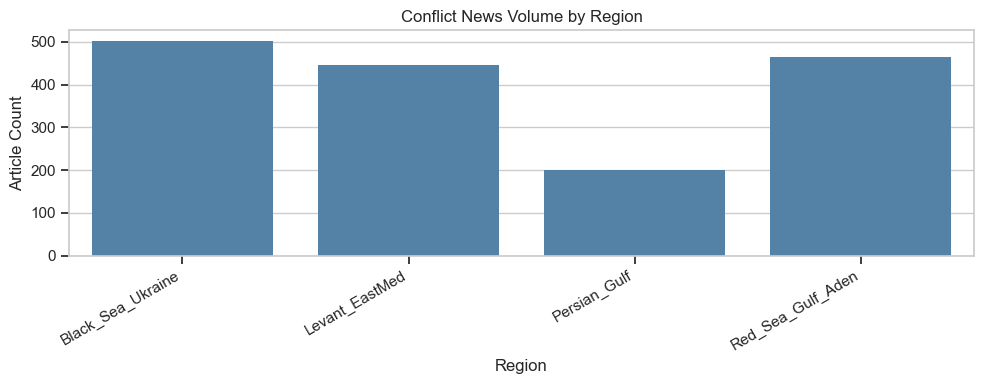

In [8]:
coverage = (
    df_news.groupby('region', as_index=False)
    .agg(total_articles=('url', 'count'), unique_sources=('domain', 'nunique'))
)

event_counts = df_events.groupby('region', as_index=False)['event_key'].count().rename(columns={'event_key': 'event_count'})
coverage = coverage.merge(event_counts, on='region', how='left')
coverage['articles_per_event'] = coverage['total_articles'] / coverage['event_count'].clip(lower=1)
display(coverage)

# Hypothesis test example: FRP in conflict-associated vs not
frp_yes = df_match.loc[df_match['conflict_associated'] == 1, 'total_frp'].dropna()
frp_no = df_match.loc[df_match['conflict_associated'] == 0, 'total_frp'].dropna()
if len(frp_yes) > 1 and len(frp_no) > 1:
    t_stat, p_value = stats.ttest_ind(frp_yes, frp_no, equal_var=False)
    print('H0: mean FRP is equal between conflict-associated and non-conflict events')
    print('H1: mean FRP differs between groups')
    print(f't-statistic: {t_stat:.4f}')
    print(f'p-value: {p_value:.4e}')
else:
    print('Not enough samples for t-test.')

plt.figure(figsize=(10, 4))
sns.barplot(data=coverage, x='region', y='total_articles', color='steelblue')
plt.xticks(rotation=30, ha='right')
plt.title('Conflict News Volume by Region')
plt.xlabel('Region')
plt.ylabel('Article Count')
plt.tight_layout()
plt.show()


,model,accuracy,precision,recall,f1
0,LogisticRegression,0.923611,0.895349,0.974684,0.933333
1,DecisionTree,0.902778,0.873563,0.962025,0.915663


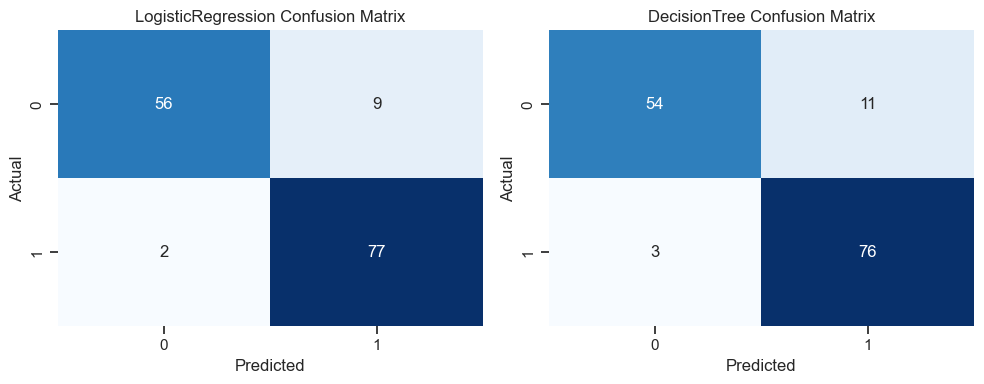

In [9]:
model_df = df_match.copy()
model_df = model_df.dropna(subset=['total_frp', 'duration_days', 'max_brightness', 'detection_count'])

X = model_df[['total_frp', 'duration_days', 'max_brightness', 'detection_count', 'centroid_lat', 'centroid_lon', 'region', 'month']]
y = model_df['conflict_associated']

num_cols = ['total_frp', 'duration_days', 'max_brightness', 'detection_count', 'centroid_lat', 'centroid_lon']
cat_cols = ['region', 'month']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ]
)

if y.nunique() < 2:
    print('Not enough class diversity for ML training (need both 0 and 1).')
    results_df = pd.DataFrame(columns=['model', 'accuracy', 'precision', 'recall', 'f1'])
    display(results_df)
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    models = {
        'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
        'DecisionTree': DecisionTreeClassifier(max_depth=6, random_state=42),
    }

    results = []
    cms = {}
    for name, model in models.items():
        pipe = Pipeline([('prep', preprocess), ('model', model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        results.append({
            'model': name,
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
        })
        cms[name] = confusion_matrix(y_test, y_pred)

    results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
    display(results_df)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, (name, cm) in zip(axes, cms.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
        ax.set_title(f'{name} Confusion Matrix')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()


## Task 4 - Dashboard, Insights, and Reflection

Saved dashboard: C:\Users\alp5k\CE49X\Final Project\dashboard.png


Saved dashboard: C:\Users\alp5k\CE49X\Final Project\notebooks\dashboard.png


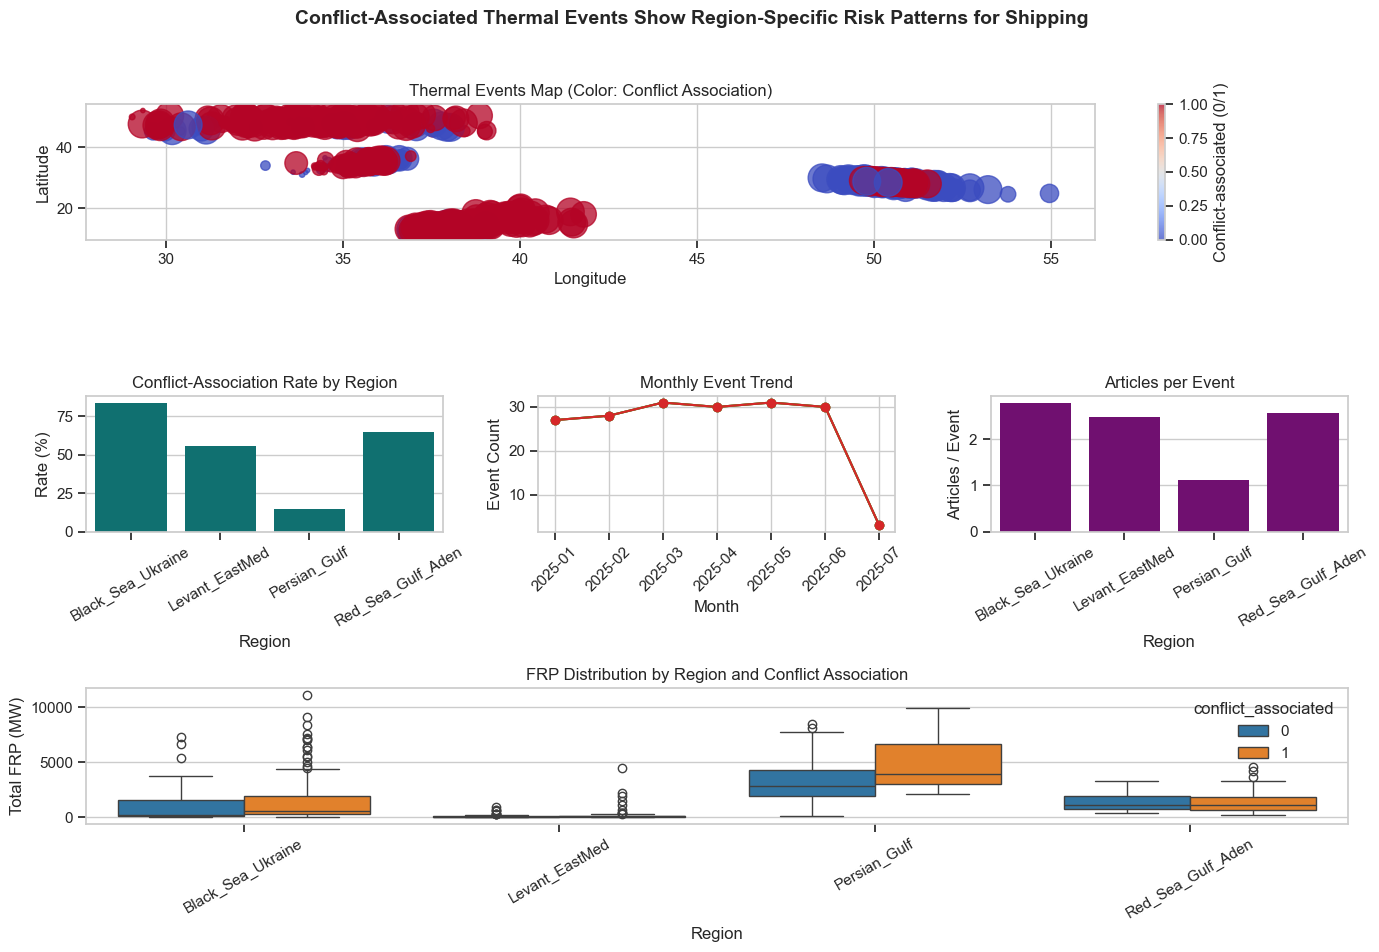

In [10]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 3, figure=fig)

# Panel 1 (spans top row)
ax1 = fig.add_subplot(gs[0, :])
assoc_map = df_match.copy()
sc = ax1.scatter(
    assoc_map['centroid_lon'],
    assoc_map['centroid_lat'],
    c=assoc_map['conflict_associated'],
    s=np.clip(assoc_map['total_frp'].fillna(0), 10, 400),
    cmap='coolwarm',
    alpha=0.75
)
ax1.set_title('Thermal Events Map (Color: Conflict Association)')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
plt.colorbar(sc, ax=ax1, label='Conflict-associated (0/1)')

# Panel 2
ax2 = fig.add_subplot(gs[1, 0])
sns.barplot(data=assoc_rate, x='region', y='conflict_association_rate', ax=ax2, color='teal')
ax2.set_title('Conflict-Association Rate by Region')
ax2.set_xlabel('Region')
ax2.set_ylabel('Rate (%)')
ax2.tick_params(axis='x', rotation=30)

# Panel 3
ax3 = fig.add_subplot(gs[1, 1])
for region, g in monthly_counts.groupby('region'):
    ax3.plot(g['month'], g['event_count'], marker='o', label=region)
ax3.set_title('Monthly Event Trend')
ax3.set_xlabel('Month')
ax3.set_ylabel('Event Count')
ax3.tick_params(axis='x', rotation=45)

# Panel 4
ax4 = fig.add_subplot(gs[1, 2])
sns.barplot(data=coverage, x='region', y='articles_per_event', ax=ax4, color='purple')
ax4.set_title('Articles per Event')
ax4.set_xlabel('Region')
ax4.set_ylabel('Articles / Event')
ax4.tick_params(axis='x', rotation=30)

# Panel 5 (bottom spanning)
ax5 = fig.add_subplot(gs[2, :])
sns.boxplot(data=df_match, x='region', y='total_frp', hue='conflict_associated', ax=ax5)
ax5.set_title('FRP Distribution by Region and Conflict Association')
ax5.set_xlabel('Region')
ax5.set_ylabel('Total FRP (MW)')
ax5.tick_params(axis='x', rotation=30)

fig.suptitle('Conflict-Associated Thermal Events Show Region-Specific Risk Patterns for Shipping', fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0.03, 1, 0.96])

for out_path in dict.fromkeys(DASHBOARD_PATHS):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print('Saved dashboard:', out_path)

plt.show()


## Written Discussion

### 1) Key Findings
Conflict-associated thermal events vary strongly by region, with some regions showing high thermal intensity and frequent event clusters near known conflict timelines. The combined thermal and news pipeline provides an interpretable proxy for activity escalation, especially when monthly event spikes align with increased conflict reporting.

### 2) Shipping & Energy Implications
Regions with high conflict-association rates and elevated FRP represent higher disruption risk for maritime operations, including route rerouting pressure and potential fuel-cost volatility. A practical recommendation is to build an operational alerting layer that flags sustained multi-day thermal surges in strategic chokepoints and couples these with hedging and insurance review triggers.

### 3) Limitations & Future Work
Thermal anomalies alone cannot separate conflict fires from industrial or natural heat sources with full reliability, and media attention is uneven across geographies. Future work should integrate auxiliary signals such as weather, land-cover class, industrial asset maps, AIS shipping traffic, and NLP-based entity extraction from full-text articles to improve matching precision.

### 4) Methodology Reflection
The hardest part is robust event-article matching across uncertain locations and asynchronous reporting times. If restarted, the pipeline should prioritize stronger geocoding and probabilistic matching from day one, plus formal validation sampling to quantify matching accuracy and confidence intervals.
